In [5]:
import pandas as pd
from mypy.typeops import false_only
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
torch.manual_seed(23)

In [9]:
df = pd.read_csv('fmnist_small.csv')

In [10]:
df.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
5,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,130,0,0,0,0,0,0,0,0,0
9,0,0,0,0,1,1,3,0,0,0,...,80,77,83,45,0,0,0,1,0,0


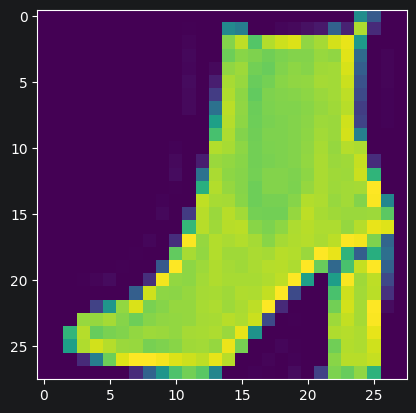

In [16]:
plt.imshow(df.iloc[0, 1:].values.reshape(28,28))

In [17]:
X = df.iloc[:,1:].values
y=df.iloc[:,0].values

In [18]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [19]:
X_train = X_train/255.0

In [20]:
X_test=X_test/255.0

In [62]:
class customDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32, device=torch.device('cuda:0'))
        self.y = torch.tensor(y, dtype=torch.long, device=torch.device('cuda:0'))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [63]:
dataset = customDataset(X_train, y_train)

In [64]:
train_dataloader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)

In [65]:
test_dataset = customDataset(X_test, y_test)

In [66]:
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False, pin_memory_device=torch.cuda.current_device())

In [67]:
class SimpleNN(nn.Module):
    def __init__(self,num_features):
        super( ).__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [68]:
model = SimpleNN(train_dataloader.dataset.X.shape[1])

In [69]:
epochs =100
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [70]:
for epoch in range(epochs):
    total_epoch_loss=0

    for batch_features, batch_labels in train_dataloader:
        out = model(batch_features)
        optimizer.zero_grad()
        loss = criterion(out, batch_labels)
        loss.backward()
        optimizer.step()
        total_epoch_loss+=loss.item()
    avg_loss = total_epoch_loss/len(train_dataloader)

    print("Epoch : ",epoch+1 , 'Loss:', avg_loss)



RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [61]:
from torchinfo import summary

In [44]:
summary(model)

Layer (type:depth-idx)                   Param #
SimpleNN                                 --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       100,480
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0

In [45]:
model.eval()

SimpleNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [51]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_dataloader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    predicted = torch.tensor(predicted, device=torch.device('cuda:0'))

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)